In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Setup successful!")
train = pd.read_csv("../data/raw/train.csv")
store = pd.read_csv("../data/raw/store.csv")

print("Train shape:", train.shape)
print("Store shape:", store.shape)

print("TRAIN DATA")
display(train.head())

print("\nSTORE DATA")
display(store.head())

print("TRAIN INFO")
train.info()

print("\nSTORE INFO")
store.info()

print("Missing values in train:")
display(train.isnull().sum().sort_values(ascending=False))

print("\nMissing values in store:")
display(store.isnull().sum().sort_values(ascending=False))


Setup successful!
Train shape: (1017209, 9)
Store shape: (1115, 10)
TRAIN DATA


C:\Users\HP\AppData\Local\Temp\ipykernel_9544\3846972447.py:6: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1



STORE DATA


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB

STORE INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-nul

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


Missing values in store:


PromoInterval                544
Promo2SinceYear              544
Promo2SinceWeek              544
CompetitionOpenSinceYear     354
CompetitionOpenSinceMonth    354
CompetitionDistance            3
StoreType                      0
Store                          0
Assortment                     0
Promo2                         0
dtype: int64

In [14]:
promo_check = store.groupby("Promo2")[
    ["Promo2SinceWeek", "Promo2SinceYear", "PromoInterval"]
].apply(lambda x: x.isnull().sum())

promo_check

,Promo2SinceWeek,Promo2SinceYear,PromoInterval
Promo2,,,
0,544,544,544
1,0,0,0


In [15]:
print("StateHoliday values:")
print(train["StateHoliday"].value_counts(dropna=False))

print("\nStoreType values:")
print(store["StoreType"].value_counts(dropna=False))

print("\nAssortment values:")
print(store["Assortment"].value_counts(dropna=False))

StateHoliday values:
StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64

StoreType values:
StoreType
a    602
d    348
c    148
b     17
Name: count, dtype: int64

Assortment values:
Assortment
a    593
c    513
b      9
Name: count, dtype: int64


In [16]:
# Standardize StateHoliday as string
train["StateHoliday"] = train["StateHoliday"].astype(str)

print(train["StateHoliday"].value_counts())

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64


In [17]:
store["CompetitionDistance"] = store["CompetitionDistance"].fillna(
    store["CompetitionDistance"].median()
)

print("Missing CompetitionDistance:",
      store["CompetitionDistance"].isnull().sum())

Missing CompetitionDistance: 0


In [18]:
df = train.merge(
    store,
    on="Store",
    how="left",
    validate="many_to_one"
)

print("Merged shape:", df.shape)
df.head()

Merged shape: (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [19]:
# Convert Date to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Create time-based features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter

print(df[
    ["Date", "Year", "Month", "Day", "WeekOfYear", "Quarter"]
].head())

        Date  Year  Month  Day  WeekOfYear  Quarter
0 2015-07-31  2015      7   31          31        3
1 2015-07-31  2015      7   31          31        3
2 2015-07-31  2015      7   31          31        3
3 2015-07-31  2015      7   31          31        3
4 2015-07-31  2015      7   31          31        3


In [20]:
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())
print("Total days:", df["Date"].nunique())

Start date: 2013-01-01 00:00:00
End date: 2015-07-31 00:00:00
Total days: 942


In [21]:
open_df = df[df["Open"] == 1].copy()

print("All rows:", len(df))
print("Open-store rows:", len(open_df))
print("Closed-store rows:", len(df) - len(open_df))

All rows: 1017209
Open-store rows: 844392
Closed-store rows: 172817


Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64


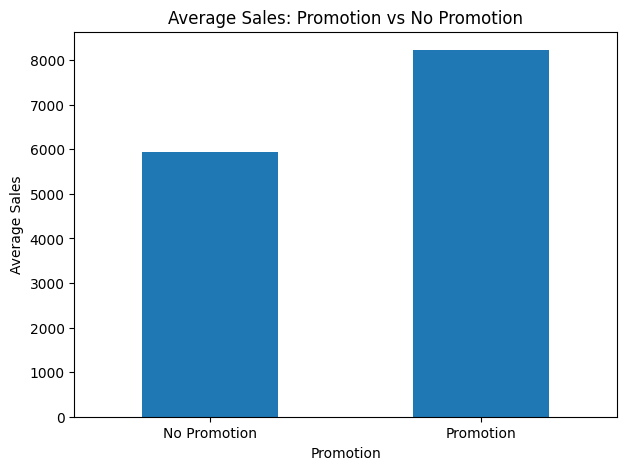

In [22]:
promo_sales = open_df.groupby("Promo")["Sales"].mean()

print(promo_sales)

promo_sales.plot(
    kind="bar",
    figsize=(7, 5),
    title="Average Sales: Promotion vs No Promotion"
)

plt.xlabel("Promotion")
plt.ylabel("Average Sales")
plt.xticks([0, 1], ["No Promotion", "Promotion"], rotation=0)
plt.show()

In [23]:
no_promo = promo_sales[0]
with_promo = promo_sales[1]

uplift = ((with_promo - no_promo) / no_promo) * 100

print(f"Average sales without promotion: {no_promo:.2f}")
print(f"Average sales with promotion: {with_promo:.2f}")
print(f"Observed promotion uplift: {uplift:.2f}%")

Average sales without promotion: 5929.41
Average sales with promotion: 8228.28
Observed promotion uplift: 38.77%


DayOfWeek
1    8216.073074
2    7088.113656
3    6728.122978
4    6767.310159
5    7072.677012
6    5874.840238
7    8224.723908
Name: Sales, dtype: float64


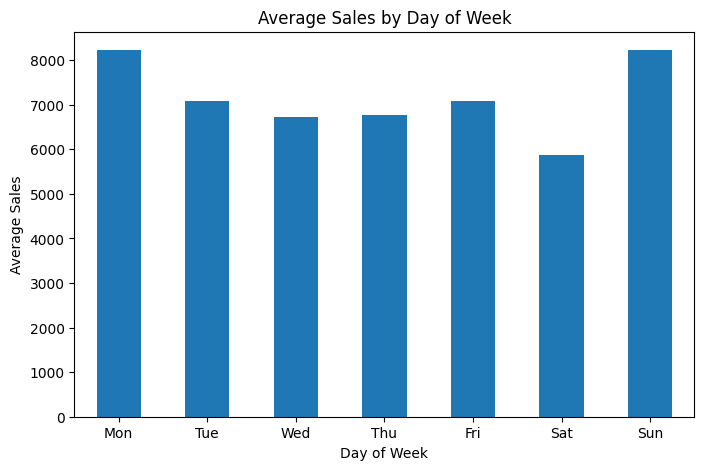

In [24]:
weekday_sales = open_df.groupby("DayOfWeek")["Sales"].mean()

print(weekday_sales)

weekday_sales.plot(
    kind="bar",
    figsize=(8, 5),
    title="Average Sales by Day of Week"
)

plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.xticks(
    range(7),
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    rotation=0
)
plt.show()

In [25]:
promo_weekday = open_df.pivot_table(
    values="Sales",
    index="DayOfWeek",
    columns="Promo",
    aggfunc="mean"
)

promo_weekday.columns = ["No_Promo", "Promo"]

promo_weekday["Uplift_%"] = (
    (promo_weekday["Promo"] - promo_weekday["No_Promo"])
    / promo_weekday["No_Promo"]
) * 100

promo_weekday

,No_Promo,Promo,Uplift_%
DayOfWeek,,,
1,6222.521495,9772.784369,57.055052
2,5716.241087,8277.201522,44.801477
3,5617.044778,7685.077816,36.817101
4,5749.837412,7598.070761,32.144098
5,6344.030127,7744.066219,22.068560
6,5874.840238,NaN,NaN
7,8224.723908,NaN,NaN


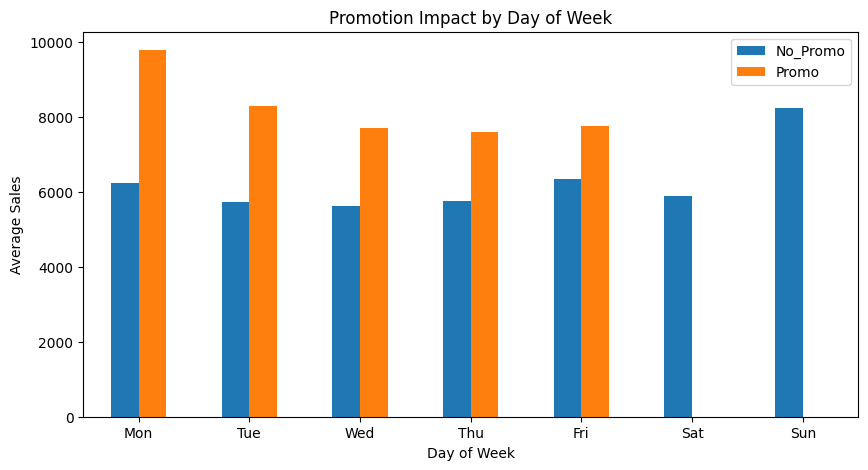

In [26]:
promo_weekday[["No_Promo", "Promo"]].plot(
    kind="bar",
    figsize=(10, 5),
    title="Promotion Impact by Day of Week"
)

plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.xticks(
    range(7),
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    rotation=0
)

plt.show()

In [27]:
promo_weekday.round(2)

,No_Promo,Promo,Uplift_%
DayOfWeek,,,
1,6222.52,9772.78,57.06
2,5716.24,8277.20,44.80
3,5617.04,7685.08,36.82
4,5749.84,7598.07,32.14
5,6344.03,7744.07,22.07
6,5874.84,NaN,NaN
7,8224.72,NaN,NaN


In [28]:
open_df.groupby("DayOfWeek")["Promo"].value_counts().unstack(fill_value=0)

Promo,0,1
DayOfWeek,,
1,60317,77243
2,66843,77118
3,65679,76257
4,60521,74123
5,66485,72155
6,144058,0
7,3593,0


In [29]:
store_type_analysis = open_df.groupby("StoreType").agg(
    Average_Sales=("Sales", "mean"),
    Median_Sales=("Sales", "median"),
    Total_Sales=("Sales", "sum"),
    Average_Customers=("Customers", "mean"),
    Observations=("Sales", "count")
)

store_type_analysis.round(2)

,Average_Sales,Median_Sales,Total_Sales,Average_Customers,Observations
StoreType,,,,,
a,6925.17,6285.0,3165334859,795.36,457077
b,10231.41,9130.0,159231395,2021.82,15563
c,6932.51,6407.0,783221426,815.47,112978
d,6822.14,6395.0,1765392943,606.34,258774


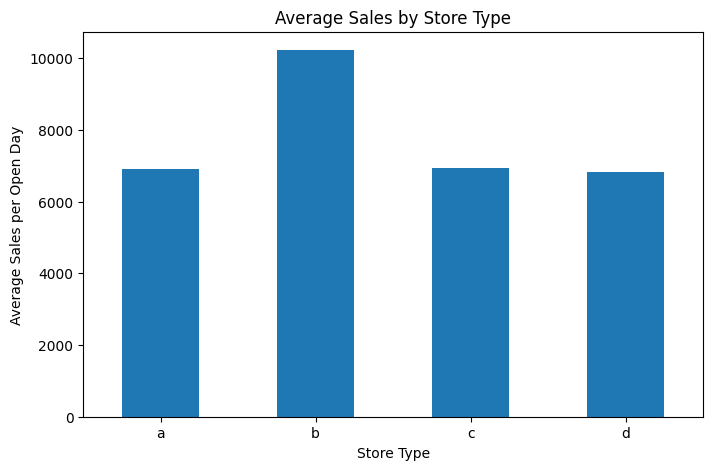

In [30]:
store_type_analysis["Average_Sales"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Average Sales by Store Type"
)

plt.xlabel("Store Type")
plt.ylabel("Average Sales per Open Day")
plt.xticks(rotation=0)
plt.show()

In [31]:
monthly_sales = (
    open_df
    .groupby(["Year", "Month"])["Sales"]
    .mean()
    .reset_index()
)

monthly_sales["YearMonth"] = pd.to_datetime(
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str)
)

monthly_sales.head()

,Year,Month,Sales,YearMonth
0,2013,1,6239.641380,2013-01-01
1,2013,2,6428.597796,2013-02-01
2,2013,3,7212.834110,2013-03-01
3,2013,4,6579.319656,2013-04-01
4,2013,5,7076.217960,2013-05-01


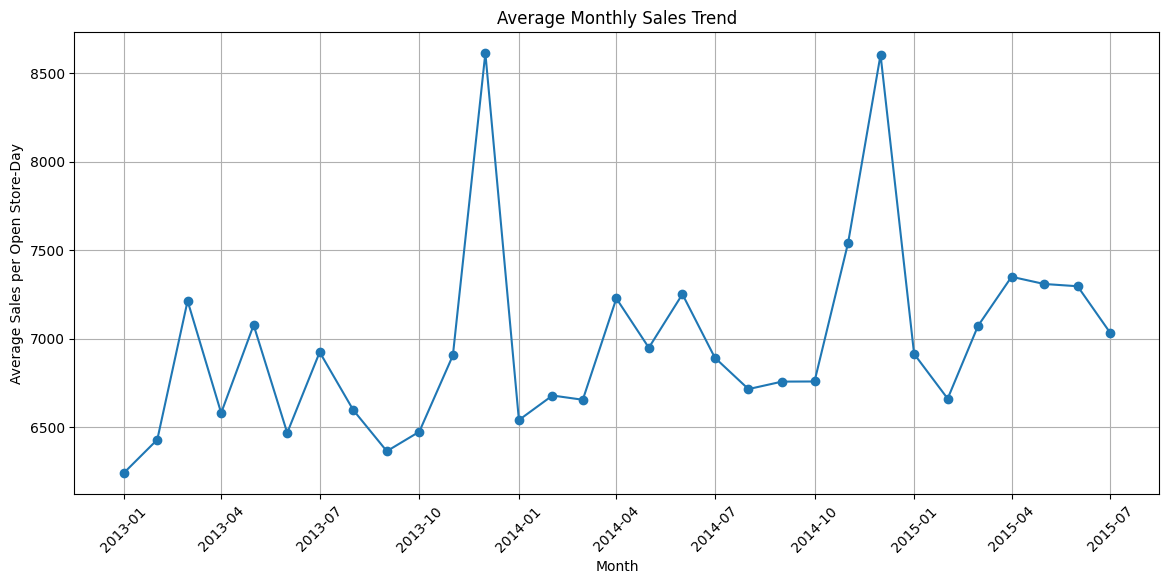

In [32]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Average Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Average Sales per Open Store-Day")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [33]:
monthly_promo_analysis = (
    open_df
    .groupby(["Year", "Month", "Promo"])["Sales"]
    .mean()
    .reset_index()
)

monthly_promo_analysis["YearMonth"] = pd.to_datetime(
    monthly_promo_analysis["Year"].astype(str)
    + "-"
    + monthly_promo_analysis["Month"].astype(str)
)

monthly_promo_analysis.head()

,Year,Month,Promo,Sales,YearMonth
0,2013,1,0,5445.915815,2013-01-01
1,2013,1,1,7517.149959,2013-01-01
2,2013,2,0,5580.481294,2013-02-01
3,2013,2,1,7619.246396,2013-02-01
4,2013,3,0,5953.311253,2013-03-01


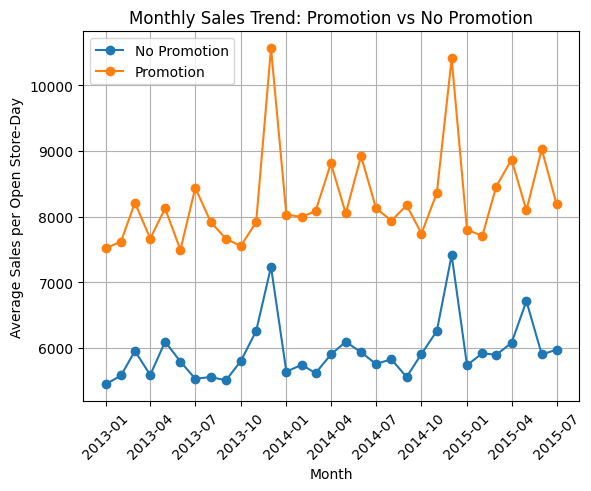

In [34]:
for promo_value, label in [(0, "No Promotion"), (1, "Promotion")]:
    subset = monthly_promo_analysis[
        monthly_promo_analysis["Promo"] == promo_value
    ]

    plt.plot(
        subset["YearMonth"],
        subset["Sales"],
        marker="o",
        label=label
    )

plt.title("Monthly Sales Trend: Promotion vs No Promotion")
plt.xlabel("Month")
plt.ylabel("Average Sales per Open Store-Day")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [35]:
customer_analysis = open_df.groupby("StoreType").agg(
    Average_Sales=("Sales", "mean"),
    Average_Customers=("Customers", "mean")
)

customer_analysis["Sales_Per_Customer"] = (
    customer_analysis["Average_Sales"]
    / customer_analysis["Average_Customers"]
)

customer_analysis.round(2)

,Average_Sales,Average_Customers,Sales_Per_Customer
StoreType,,,
a,6925.17,795.36,8.71
b,10231.41,2021.82,5.06
c,6932.51,815.47,8.50
d,6822.14,606.34,11.25


In [36]:
holiday_analysis = (
    open_df
    .groupby("StateHoliday")["Sales"]
    .agg(["mean", "median", "count"])
)

holiday_analysis.round(2)

,mean,median,count
StateHoliday,,,
0,6953.52,6368.0,843482
a,8487.47,7556.0,694
b,9887.89,8423.0,145
c,9743.75,8397.0,71
